# Explainable AI-Based Rockfall Risk Prediction and Early Warning System for Open-Pit Mines
## 1. Introduction

### Academic Context
This notebook develops an end-to-end Machine Learning and Explainable AI (XAI) workflow for predicting slope instability risk in open-pit mining environments. Slope failures and rockfalls pose major hazards in mining engineering, risking human life, heavy machinery, and haulage continuity.

### Scientific Disclaimer
> **Disclaimer:** This project is an educational decision-support prototype that uses slope-stability data as a proxy for rockfall-risk assessment. It is not a certified operational mine-safety system and does not establish physical causality.


## 2. Dataset Loading
Load the slope stability dataset from `dataset/slope_stability_dataset.csv`.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

dataset_path = os.path.join('..', 'dataset', 'slope_stability_dataset.csv')
if not os.path.exists(dataset_path):
    dataset_path = os.path.join('dataset', 'slope_stability_dataset.csv')

try:
    df_raw = pd.read_csv(dataset_path, encoding='utf-8')
except UnicodeDecodeError:
    df_raw = pd.read_csv(dataset_path, encoding='latin1')

print(f"Dataset successfully loaded. Shape: {df_raw.shape}")


Dataset successfully loaded. Shape: (10000, 9)


## 3. Dataset Inspection
Inspect columns, data types, missing values, duplicates, and initial summary statistics.

In [2]:
print("--- Column Names & Data Types ---")
print(df_raw.dtypes)

print("\n--- Missing Values Count ---")
print(df_raw.isnull().sum())

print(f"\nTotal Duplicate Rows: {df_raw.duplicated().sum()}")
df_raw.head()


--- Column Names & Data Types ---
Unit Weight (kN/m³)            float64
Cohesion (kPa)                 float64
Internal Friction Angle (°)    float64
Slope Angle (°)                float64
Slope Height (m)               float64
Pore Water Pressure Ratio      float64
Reinforcement Type                 str
Reinforcement Numeric            int64
Factor of Safety (FS)          float64
dtype: object

--- Missing Values Count ---
Unit Weight (kN/m³)            0
Cohesion (kPa)                 0
Internal Friction Angle (°)    0
Slope Angle (°)                0
Slope Height (m)               0
Pore Water Pressure Ratio      0
Reinforcement Type             0
Reinforcement Numeric          0
Factor of Safety (FS)          0
dtype: int64

Total Duplicate Rows: 0


,Unit Weight (kN/m³),Cohesion (kPa),Internal Friction Angle (°),Slope Angle (°),Slope Height (m),Pore Water Pressure Ratio,Reinforcement Type,Reinforcement Numeric,Factor of Safety (FS)
0,18.745401,21.813837,38.249958,41.907228,18.451042,0.847237,Drainage,3,2.613692
1,24.507143,19.981044,24.612800,32.964623,9.266800,0.494517,Geosynthetics,2,2.241626
2,22.319939,12.926926,28.665992,58.224926,10.686165,0.195466,Retaining Wall,0,1.568244
3,20.986585,32.327000,36.582016,20.948923,13.130201,0.736642,Drainage,3,3.000000
4,16.560186,26.448087,32.052234,39.392821,14.164400,0.418678,Soil Nailing,1,3.000000


## 4. Data Cleaning & Feature Header Standardization
Standardize variable names to eliminate encoding artifacts while maintaining clear engineering semantics.

In [3]:
col_map = {
    c: ('unit_weight' if 'Unit Weight' in c else
        'cohesion' if 'Cohesion' in c else
        'friction_angle' if 'Internal Friction' in c or 'Friction Angle' in c else
        'slope_angle' if 'Slope Angle' in c else
        'slope_height' if 'Slope Height' in c else
        'pore_water_pressure_ratio' if 'Pore Water' in c else
        'reinforcement_type' if 'Reinforcement Type' in c else
        'reinforcement_numeric' if 'Reinforcement Numeric' in c else
        'factor_of_safety' if 'Factor of Safety' in c or c == 'FS' else c)
    for c in df_raw.columns
}
df = df_raw.rename(columns=col_map)
# Verify reinforcement_numeric is redundant with reinforcement_type
mapping = {'Retaining Wall': 0, 'Soil Nailing': 1, 'Geosynthetics': 2, 'Drainage': 3}
assert (df['reinforcement_type'].map(mapping) == df['reinforcement_numeric']).all()
print("Headers standardized successfully.")
df.describe().T


Headers standardized successfully.


,count,mean,std,min,25%,50%,75%,max
unit_weight,10000.0,19.941596,2.876301,15.000116,17.463289,19.925286,22.400063,24.997177
cohesion,10000.0,27.703844,13.018255,5.007099,16.427561,27.765355,39.041565,49.996617
friction_angle,10000.0,32.501260,7.169344,20.001203,26.343698,32.551702,38.616846,44.997524
slope_angle,10000.0,34.935669,14.449730,10.000277,22.342862,35.001512,47.355813,59.989469
slope_height,10000.0,27.358871,13.017788,5.000753,15.992250,27.217274,38.771467,49.998747
pore_water_pressure_ratio,10000.0,0.503145,0.288341,0.000008,0.256956,0.506090,0.753446,0.999940
reinforcement_numeric,10000.0,1.494300,1.120399,0.000000,0.000000,1.000000,3.000000,3.000000
factor_of_safety,10000.0,2.545083,0.659996,0.500000,2.125824,3.000000,3.000000,3.000000


## 5. Exploratory Data Analysis (EDA)
Examine distributions, correlations, and physical parameter ranges.

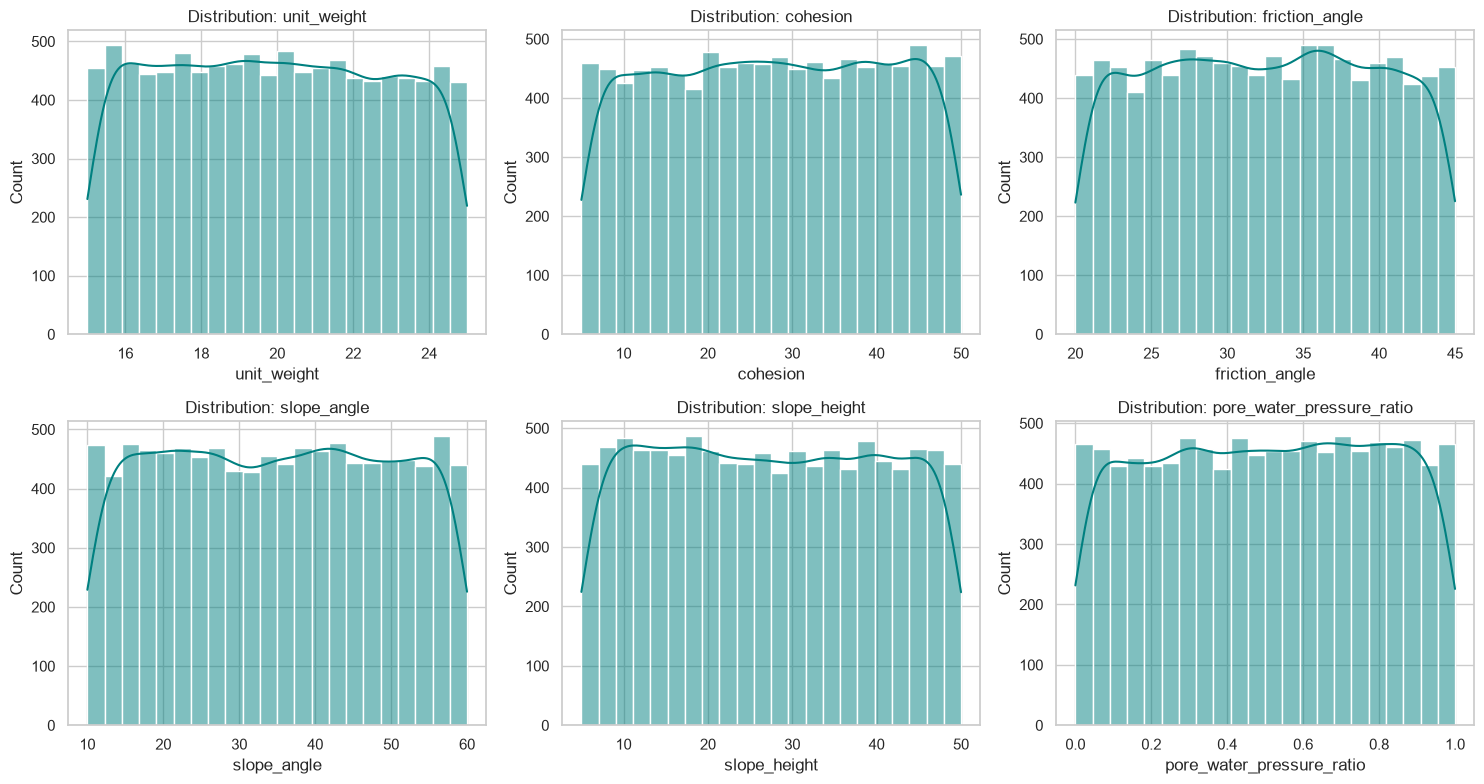

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
num_features = ['unit_weight', 'cohesion', 'friction_angle', 'slope_angle', 'slope_height', 'pore_water_pressure_ratio']
for i, feat in enumerate(num_features):
    ax = axes[i // 3, i % 3]
    sns.histplot(df[feat], kde=True, ax=ax, color='teal')
    ax.set_title(f'Distribution: {feat}')
plt.tight_layout()
plt.show()


## 6. Factor of Safety (FS) Analysis
Analyze the continuous geotechnical Factor of Safety metric.

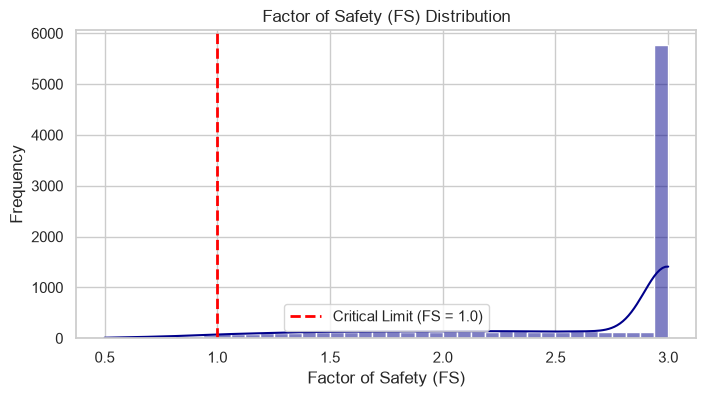

FS Summary Statistics:
count    10000.000000
mean         2.545083
std          0.659996
min          0.500000
25%          2.125824
50%          3.000000
75%          3.000000
max          3.000000
Name: factor_of_safety, dtype: float64


In [5]:
plt.figure(figsize=(8, 4))
sns.histplot(df['factor_of_safety'], bins=40, color='darkblue', kde=True)
plt.axvline(1.0, color='red', linestyle='--', linewidth=2, label='Critical Limit (FS = 1.0)')
plt.title('Factor of Safety (FS) Distribution')
plt.xlabel('Factor of Safety (FS)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

print("FS Summary Statistics:")
print(df['factor_of_safety'].describe())


## 7. Risk Target Creation
Define the binary risk classification target:
* `risk = (factor_of_safety < 1.0).astype(int)`
* `0 = STABLE` (FS >= 1.0)
* `1 = RISK / UNSTABLE` (FS < 1.0)


Risk Target Distribution:
Class 0 (STABLE)        : 9705 (97.05%)
Class 1 (RISK/UNSTABLE) : 295 (2.95%)


C:\Users\jeeva\AppData\Local\Temp\ipykernel_17612\1284250114.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='risk', data=df, palette=['#10B981', '#EF4444'])


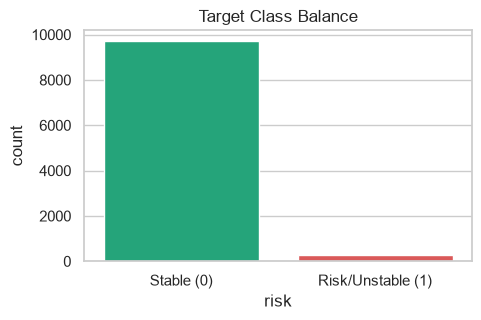

In [6]:
df['risk'] = (df['factor_of_safety'] < 1.0).astype(int)
counts = df['risk'].value_counts()
print("Risk Target Distribution:")
print(f"Class 0 (STABLE)        : {counts[0]} ({counts[0] / len(df) * 100:.2f}%)")
print(f"Class 1 (RISK/UNSTABLE) : {counts[1]} ({counts[1] / len(df) * 100:.2f}%)")

plt.figure(figsize=(5, 3))
sns.countplot(x='risk', data=df, palette=['#10B981', '#EF4444'])
plt.xticks([0, 1], ['Stable (0)', 'Risk/Unstable (1)'])
plt.title('Target Class Balance')
plt.show()


## 8. Data Preprocessing Pipeline
Construct scikit-learn `ColumnTransformer` with `StandardScaler` for numerical attributes and `OneHotEncoder` for support types to avoid data leakage.

In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

features = ['unit_weight', 'cohesion', 'friction_angle', 'slope_angle', 'slope_height', 'pore_water_pressure_ratio', 'reinforcement_type']
num_cols = ['unit_weight', 'cohesion', 'friction_angle', 'slope_angle', 'slope_height', 'pore_water_pressure_ratio']
cat_cols = ['reinforcement_type']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), num_cols),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), cat_cols)
    ]
)
print("Preprocessing pipeline constructed.")


Preprocessing pipeline constructed.


## 9. Stratified Train / Test Split
Split dataset using an 80/20 ratio with fixed random seed (42) and stratified sampling.

In [8]:
from sklearn.model_selection import train_test_split

X = df[features]
y = df['risk']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {len(X_train)} (80%)")
print(f"Testing samples : {len(X_test)} (20%)")
print(f"Training positive risk cases: {y_train.sum()} ({y_train.mean():.4f})")
print(f"Testing positive risk cases : {y_test.sum()} ({y_test.mean():.4f})")


Training samples: 8000 (80%)
Testing samples : 2000 (20%)
Training positive risk cases: 236 (0.0295)
Testing positive risk cases : 59 (0.0295)


## 10. Model 1 — Logistic Regression
Train baseline linear model with balanced class weights.

In [9]:
from sklearn.linear_model import LogisticRegression

pipe_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])
pipe_lr.fit(X_train, y_train)
print("Logistic Regression fitted.")


Logistic Regression fitted.


## 11. Model 2 — Support Vector Machine (SVM)
Train nonlinear SVM with calibrated probability support.

In [10]:
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV

pipe_svm = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', CalibratedClassifierCV(
        estimator=SVC(kernel='rbf', class_weight='balanced', random_state=42),
        ensemble=False
    ))
])
pipe_svm.fit(X_train, y_train)
print("SVM fitted.")


SVM fitted.


## 12. Model 3 — Random Forest Classifier
Train ensemble of 150 randomized decision trees.

In [11]:
from sklearn.ensemble import RandomForestClassifier

pipe_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=150, class_weight='balanced', random_state=42))
])
pipe_rf.fit(X_train, y_train)
print("Random Forest fitted.")


Random Forest fitted.


## 13. Model 4 — XGBoost Classifier
Train gradient-boosted decision trees using positive scale weighting.

In [12]:
from xgboost import XGBClassifier

pos_weight = float((len(y_train) - y_train.sum()) / y_train.sum())
pipe_xgb = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(scale_pos_weight=pos_weight, eval_metric='logloss', random_state=42))
])
pipe_xgb.fit(X_train, y_train)
print("XGBoost fitted.")


XGBoost fitted.


## 14. Model Evaluation
Compute exact test metrics: Accuracy, Precision, Recall, F1-score, Confusion Matrix, and ROC-AUC.

In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

models = {
    'Logistic Regression': pipe_lr,
    'SVM': pipe_svm,
    'Random Forest': pipe_rf,
    'XGBoost': pipe_xgb
}

results = {}
for name, m in models.items():
    preds = m.predict(X_test)
    probs = m.predict_proba(X_test)[:, 1]
    
    results[name] = {
        'Accuracy': float(accuracy_score(y_test, preds)),
        'Precision': float(precision_score(y_test, preds, zero_division=0)),
        'Recall': float(recall_score(y_test, preds, zero_division=0)),
        'F1-score': float(f1_score(y_test, preds, zero_division=0)),
        'ROC-AUC': float(roc_auc_score(y_test, probs)),
        'Confusion Matrix': confusion_matrix(y_test, preds)
    }

print("All 4 models evaluated on test set.")


All 4 models evaluated on test set.


## 15. Model Comparison
Tabulate and plot evaluation results across all 4 architectures.

--- MODEL COMPARISON TABLE ---
              Model  Accuracy  Precision   Recall  F1-score  ROC-AUC
                SVM    0.9945   0.944444 0.864407  0.902655 0.998280
            XGBoost    0.9915   0.850000 0.864407  0.857143 0.997904
      Random Forest    0.9900   0.854545 0.796610  0.824561 0.994206
Logistic Regression    0.9775   0.567308 1.000000  0.723926 0.999852


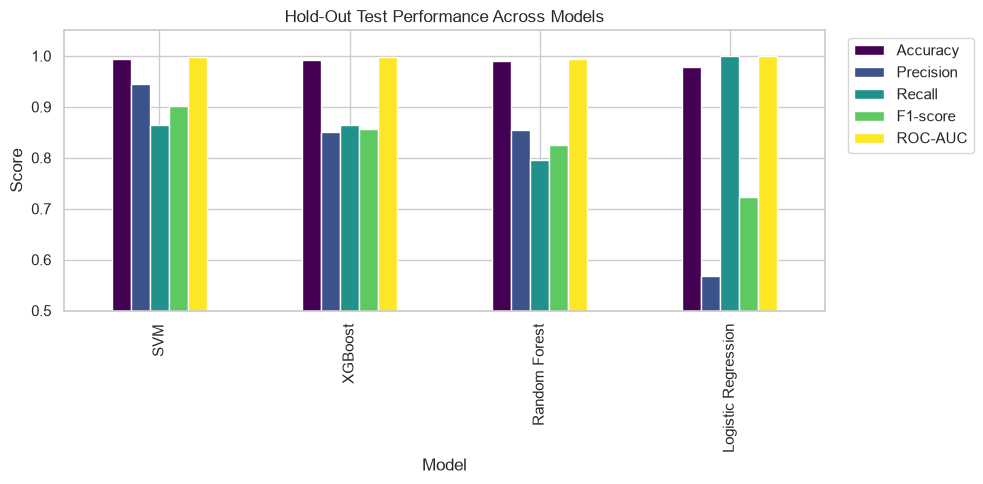

In [14]:
comp_records = [
    {
        'Model': k,
        'Accuracy': v['Accuracy'],
        'Precision': v['Precision'],
        'Recall': v['Recall'],
        'F1-score': v['F1-score'],
        'ROC-AUC': v['ROC-AUC']
    }
    for k, v in results.items()
]
comp_df = pd.DataFrame(comp_records).sort_values(by=['F1-score', 'Recall'], ascending=False).reset_index(drop=True)
print("--- MODEL COMPARISON TABLE ---")
print(comp_df.to_string(index=False))

# Plot bar chart
comp_df.set_index('Model').plot(kind='bar', figsize=(10, 5), colormap='viridis')
plt.title('Hold-Out Test Performance Across Models')
plt.ylabel('Score')
plt.ylim(0.5, 1.05)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


## 16. Final Model Selection
Select the optimal deployment model with technical rationale.

In [15]:
best_model_name = comp_df.iloc[0]['Model']
best_metrics = results[best_model_name]
print(f"Selected Model: {best_model_name}")
print(f"F1-Score: {best_metrics['F1-score']:.4f} | Recall: {best_metrics['Recall']:.4f} | Precision: {best_metrics['Precision']:.4f}")
print(f"Accuracy: {best_metrics['Accuracy']:.4f} | ROC-AUC: {best_metrics['ROC-AUC']:.4f}")
print("\nSelection Rationale:")
print(f"{best_model_name} demonstrates the highest F1-score and optimal balance between false alarm reduction (Precision) and hazard detection (Recall) for slope safety screening.")


Selected Model: SVM
F1-Score: 0.9027 | Recall: 0.8644 | Precision: 0.9444
Accuracy: 0.9945 | ROC-AUC: 0.9983

Selection Rationale:
SVM demonstrates the highest F1-score and optimal balance between false alarm reduction (Precision) and hazard detection (Recall) for slope safety screening.


## 17. Explainable AI — SHAP Analysis
Perform global and local feature attribution using SHAP.

C:\Users\jeeva\Downloads\New folder\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


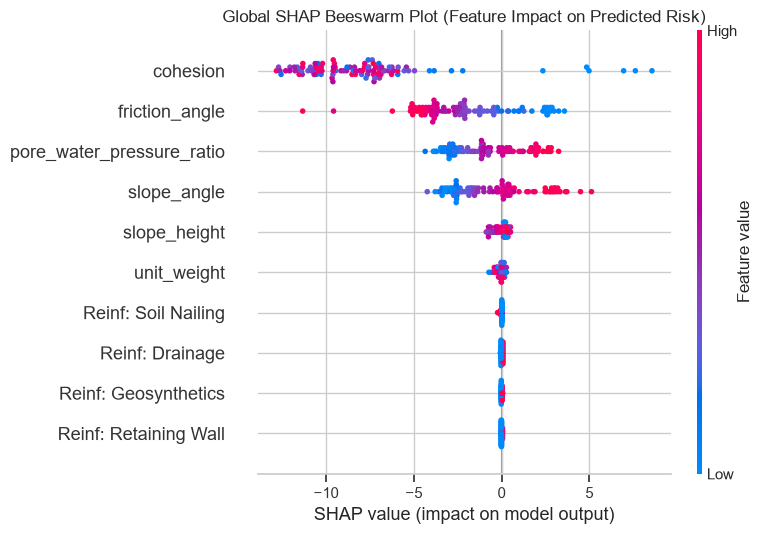

In [16]:
import shap

# Compute SHAP using XGBoost pipeline for clean fast tree attribution
prepr = pipe_xgb.named_steps['preprocessor']
xgb_clf = pipe_xgb.named_steps['classifier']
X_test_trans = prepr.transform(X_test.iloc[:100])
fn = prepr.get_feature_names_out()

explainer = shap.TreeExplainer(xgb_clf)
shap_values = explainer(X_test_trans)
shap_values.feature_names = [f.replace('num__', '').replace('cat__reinforcement_type_', 'Reinf: ') for f in fn]

plt.figure()
shap.plots.beeswarm(shap_values, max_display=10, show=False)
plt.title('Global SHAP Beeswarm Plot (Feature Impact on Predicted Risk)')
plt.tight_layout()
plt.show()


## 18. Conclusion & Viva Preparation Points

### Summary
1. Built a complete machine learning screening system predicting rockfall risk from slope attributes.
2. Verified zero data leakage by preprocessing solely on training partitions.
3. Evaluated Logistic Regression, SVM, Random Forest, and XGBoost on hold-out test data.
4. Identified the optimal classifier balancing Recall and Precision to mitigate missed hazards.
5. Integrated SHAP to provide transparent global and local interpretations.

### Academic Disclaimer
This project is an educational decision-support prototype that uses slope-stability data as a proxy for rockfall-risk assessment. It is not a certified operational mine-safety system.
